In [54]:
%load_ext autoreload
%autoreload 2

from src.dynamical_systems import *
from src.SINDyModel import *
from src.derivatives import *
from src.helpers import *

import matplotlib.pyplot as plt
from tqdm import tqdm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
# make a specific Lotka-Volterra right-hand side function
lotka_volterra_rhs = generate_lotka_volterra_rhs(1, 0.1, 1.5, 0.75)

dt = 0.01
t_span = (0, 50)

t_eval = np.arange(t_span[0], t_span[1] + dt, dt)
x0 = (10, 5)

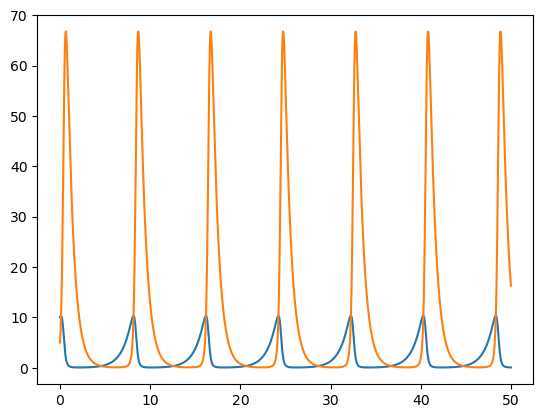

In [56]:
x_train = generate_training_data(lotka_volterra_rhs, x0, t_eval)

plt.plot(t_eval, x_train.T)
plt.show()

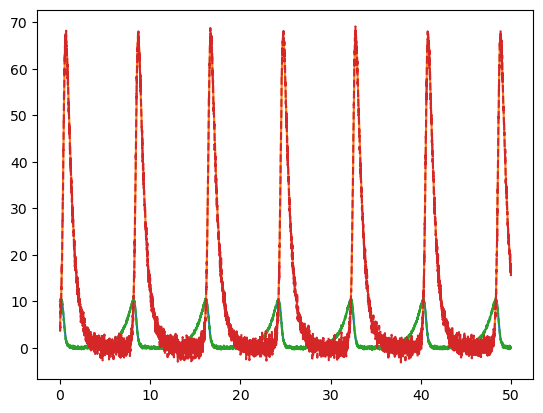

In [65]:
x_train_noisy = add_noise_to_data(x_train, 0.05)

plt.plot(t_eval, x_train.T)
plt.plot(t_eval, x_train_noisy.T, '--')
plt.show()

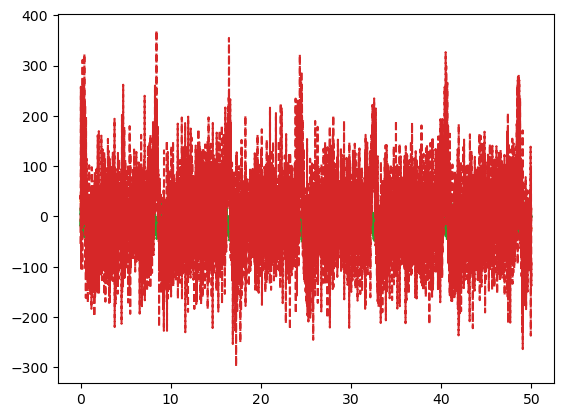

In [69]:
# generate the true derivative
x_dot_true = lotka_volterra_rhs(t_eval, x_train)

x_dot_approx = dxdt_finite_difference(x_train_noisy, t_eval)

plt.plot(t_eval, x_dot_true.T)
plt.plot(t_eval, x_dot_approx.T, '--')
plt.show()

In [70]:
# generate models for different noise levels

threshold = 0.05

noise_levels = [0, 0.0001, 0.001, 0.01, 0.1, 1]

models = []
ps_models = []
for noise_level in tqdm(noise_levels):
    # generate noisy data
    x_train_noisy = add_noise_to_data(x_train, noise_level)
    
    # generate the derivative of the noisy data
    # NOTE: we can change the kind of derivative and the parameters of the derivative method!
    x_dot_approx = dxdt_finite_difference(x_train_noisy, t_eval)

    # create and fit a SINDy model
    model = SINDyModel(n_state_vars=2, threshold=threshold, poly_order=5)
    model.fit(x_train_noisy, x_dot_approx)
    models.append(model)

    import pysindy as ps
    ps_model = ps.SINDy(optimizer=ps.STLSQ(threshold=threshold), feature_library=ps.PolynomialLibrary(degree=5))
    ps_model.fit(x_train_noisy.T, x_dot=x_dot_approx.T)
    ps_models.append(ps_model)


# print the models
for i in range(len(noise_levels)):
    print(f"noise level: {noise_levels[i]}")
    print("my model:")
    models[i].print(decimals=3)
    print("PySINDy model:")
    ps_models[i].print()
    print()

100%|██████████| 6/6 [00:00<00:00, 31.22it/s]

noise level: 0
my model:
x0' = + 1.000 x0 + -0.100 x0 x1 
x1' = + -1.500 x1 + 0.750 x0 x1 
PySINDy model:
(x0)' = 1.000 x0 + -0.100 x0 x1
(x1)' = -1.500 x1 + 0.750 x0 x1

noise level: 0.0001
my model:
x0' = + 1.000 x0 + -0.100 x0 x1 
x1' = + -1.500 x1 + 0.750 x0 x1 
PySINDy model:
(x0)' = 1.000 x0 + -0.100 x0 x1
(x1)' = -1.500 x1 + 0.750 x0 x1

noise level: 0.001
my model:
x0' = + 1.000 x0 + -0.100 x0 x1 
x1' = + -1.500 x1 + 0.750 x0 x1 
PySINDy model:
(x0)' = 1.000 x0 + -0.100 x0 x1
(x1)' = -1.500 x1 + 0.750 x0 x1

noise level: 0.01
my model:
x0' = + 0.998 x0 + -0.100 x0 x1 
x1' = + -1.500 x1 + 0.751 x0 x1 
PySINDy model:
(x0)' = 0.998 x0 + -0.100 x0 x1
(x1)' = -1.500 x1 + 0.751 x0 x1

noise level: 0.1
my model:
x0' = + 2.128 1 + -0.088 x0 + -0.198 x1 
x1' = + 0.131 x0 + -1.469 x1 + 0.734 x0 x1 
PySINDy model:
(x0)' = 2.128 1 + -0.088 x0 + -0.198 x1
(x1)' = 0.131 x0 + -1.469 x1 + 0.734 x0 x1

noise level: 1
my model:
x0' = + 0.313 1 + -0.523 x0 + -0.117 x1 + 0.064 x0^2 
x1' = + -11.99

In [50]:
# list(zip(models[0].function_library_names, ps_models[0].feature_library.get_feature_names()))
# models[0].function_library_names == ps_models[0].feature_library.get_feature_names()

In [71]:
# generate predictions for the models

x_preds = []
for model in tqdm(models):
    x_pred = generate_model_prediction(model, x0, t_eval)
    x_preds.append(x_pred)

100%|██████████| 6/6 [00:02<00:00,  2.34it/s]


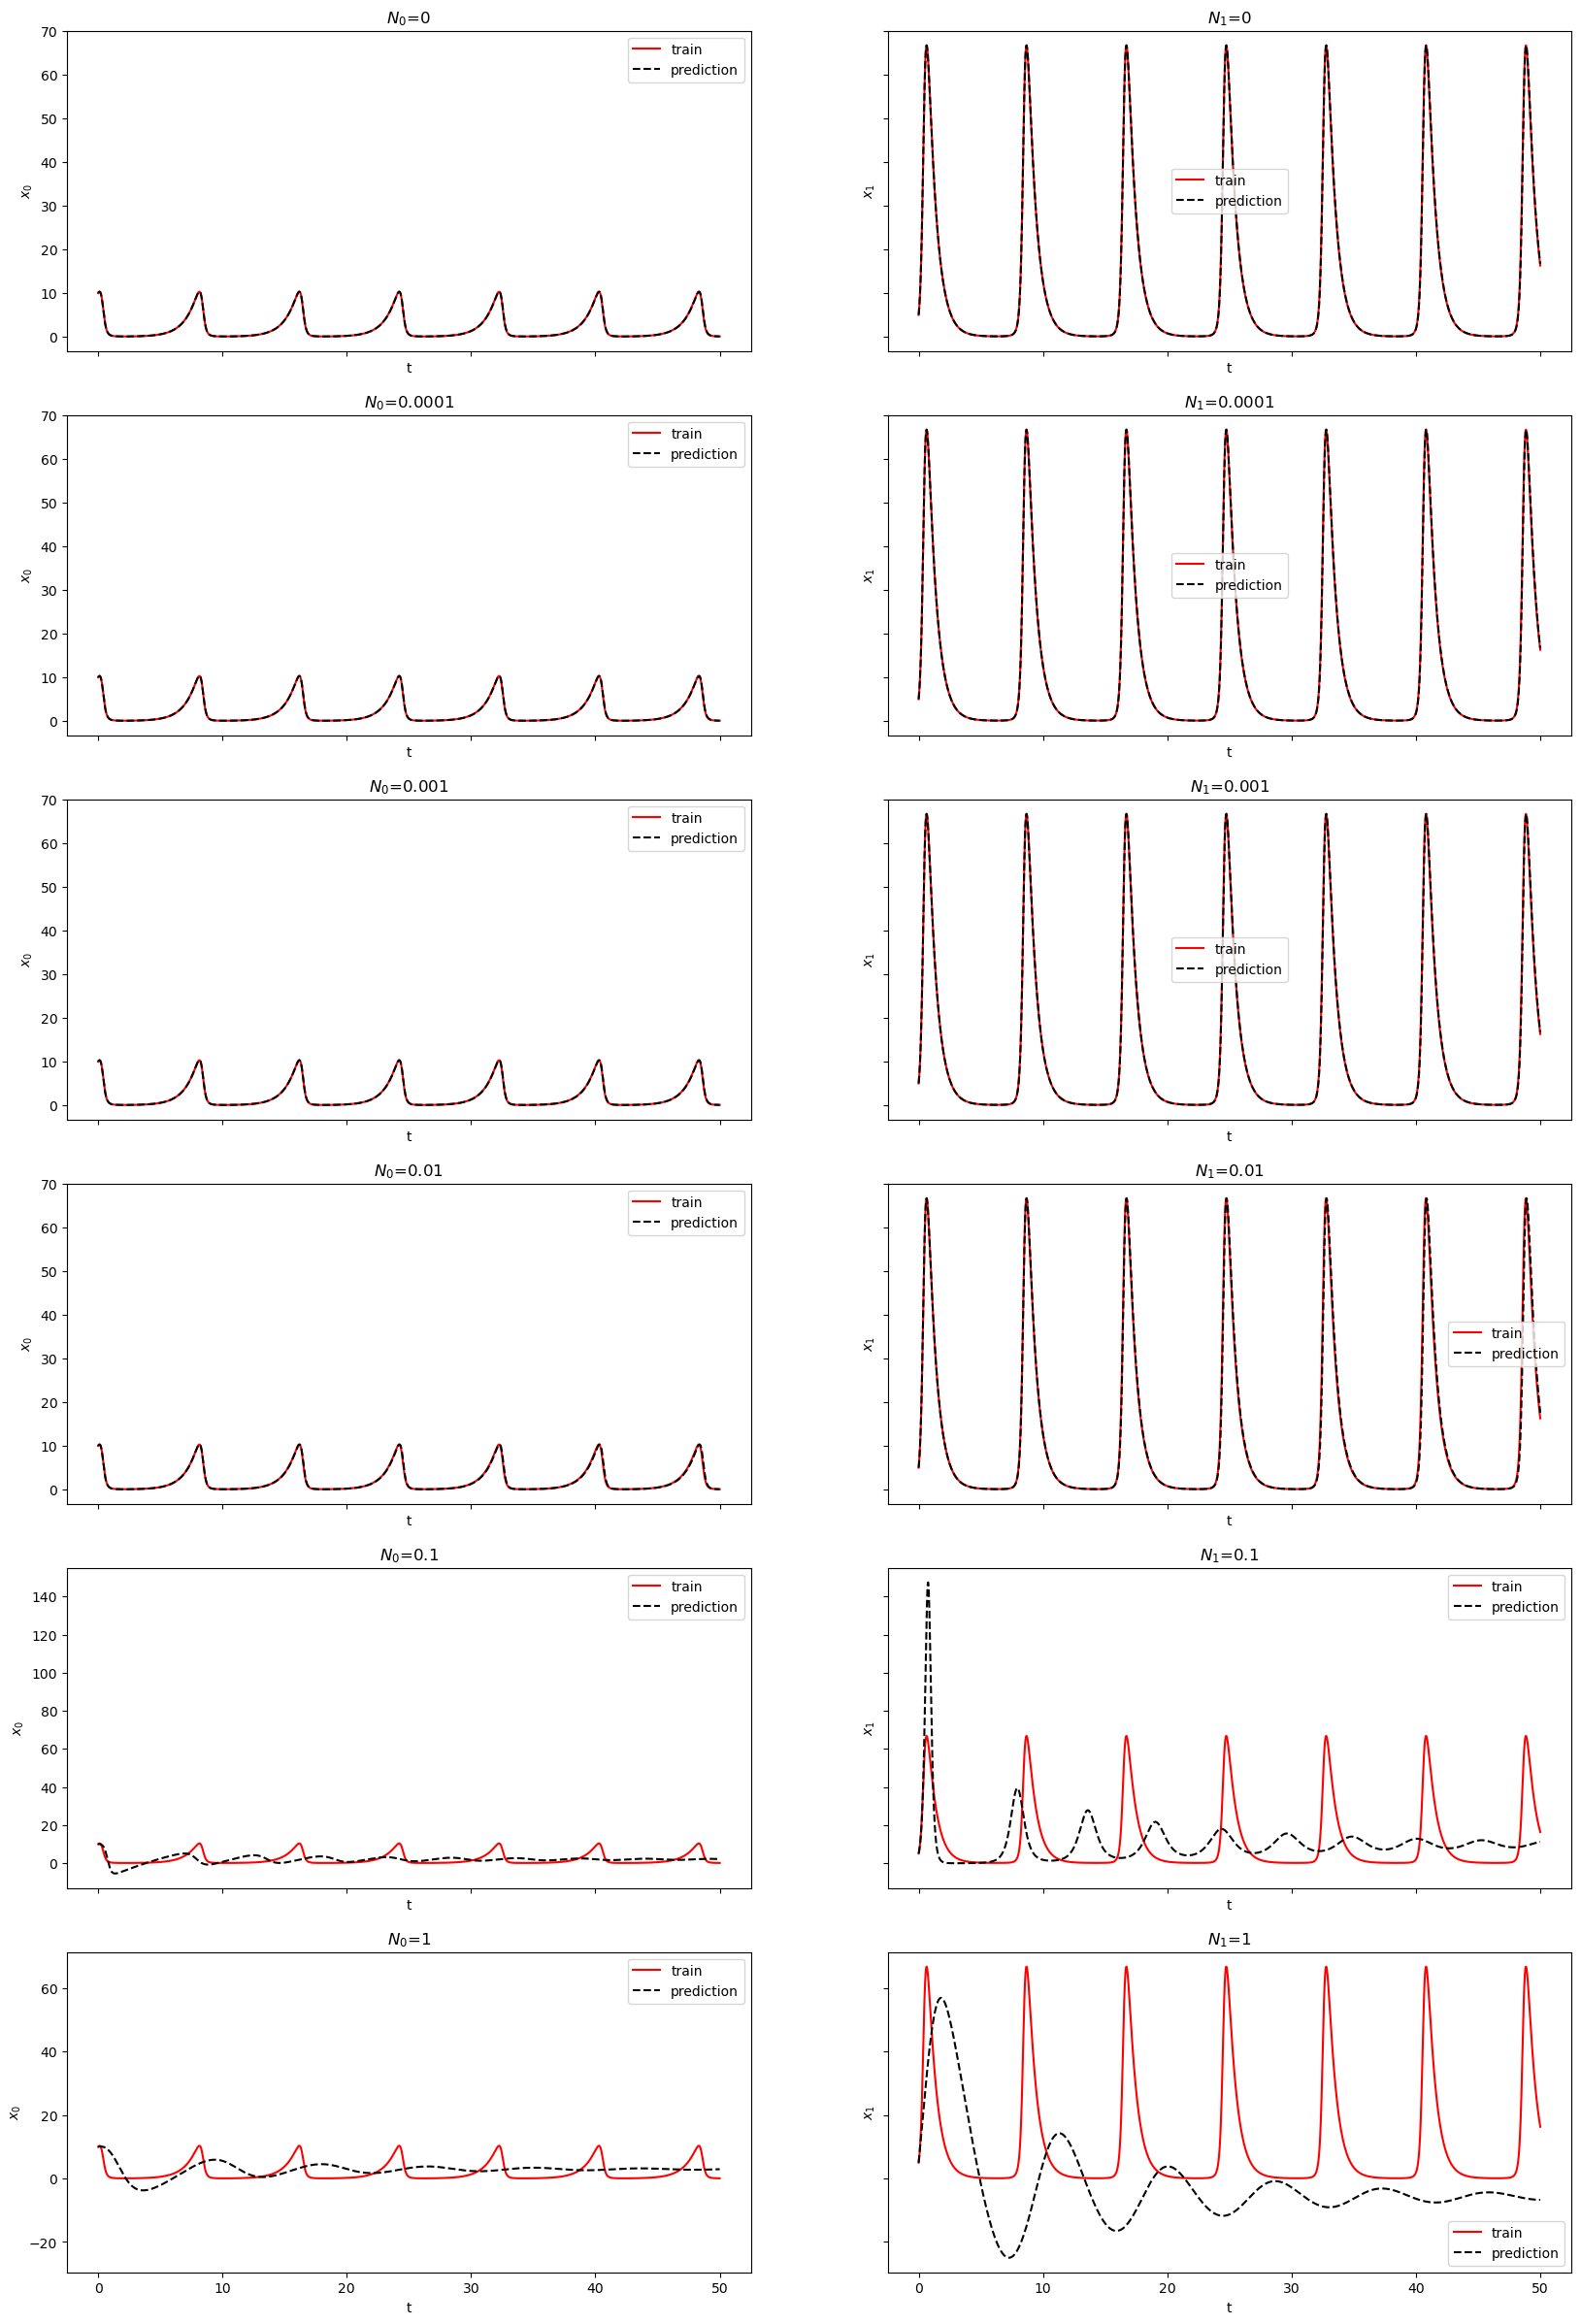

In [72]:
n_noise_levels = len(noise_levels)
n_svs = len(x0)

fig, axs = plt.subplots(n_noise_levels, n_svs, figsize=(10*n_svs, 5*n_noise_levels), sharex='col', sharey='row')

for noise_level_idx in range(n_noise_levels):
    for sv_idx in range(n_svs):
        # plot the sv_idx'th training state variable
        axs[noise_level_idx, sv_idx].plot(t_eval, x_train[sv_idx], "r", label="train")
        
        # plot the sv_idx'th state variable model prediction
        axs[noise_level_idx, sv_idx].plot(t_eval, x_preds[noise_level_idx][sv_idx], "k--", label="prediction")

        # set the title and labels
        axs[noise_level_idx, sv_idx].set_title(f"$N_{sv_idx}$={noise_levels[noise_level_idx]}")
        axs[noise_level_idx, sv_idx].set_xlabel("t")
        axs[noise_level_idx, sv_idx].set_ylabel(f"$x_{sv_idx}$")
        axs[noise_level_idx, sv_idx].legend()

fig.show()

In [73]:
for i in range(len(noise_levels)):
    rte = relative_frobenius_error(x_train, x_preds[i])
    print(f"noise level: {noise_levels[i]:.6f}, relative trajectory error: {rte:.6f}")

noise level: 0.000000, relative trajectory error: 0.017145
noise level: 0.000100, relative trajectory error: 0.017462
noise level: 0.001000, relative trajectory error: 0.019666
noise level: 0.010000, relative trajectory error: 0.056863
noise level: 0.100000, relative trajectory error: 0.908654
noise level: 1.000000, relative trajectory error: 1.248406
